In [1]:
import torch
from diffusers import DDPMPipeline
from genaibook.core import get_device

In [2]:
de=get_device()
de

device(type='cuda')

In [3]:
image_pipe = DDPMPipeline.from_pretrained("google/ddpm-celebahq-256")
image_pipe.to(de)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\91830\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\91830\.cache\huggingface\hub\models--google--ddpm-celebahq-256\snapshots\cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.35.2",
  "_name_or_path": "google/ddpm-celebahq-256",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

  0%|          | 0/1000 [00:00<?, ?it/s]

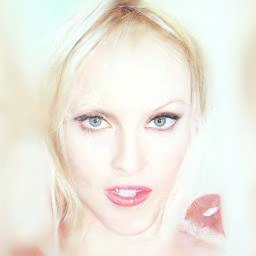

In [4]:
image_pipe().images[0]

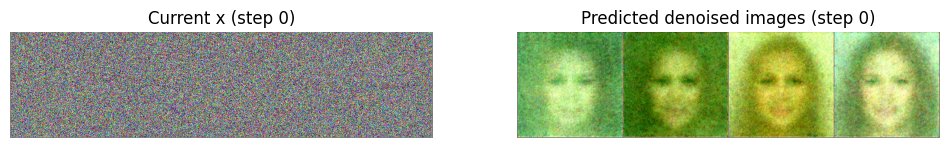

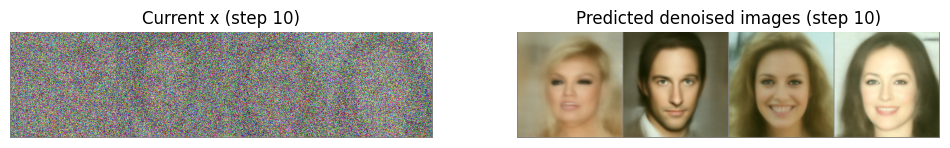

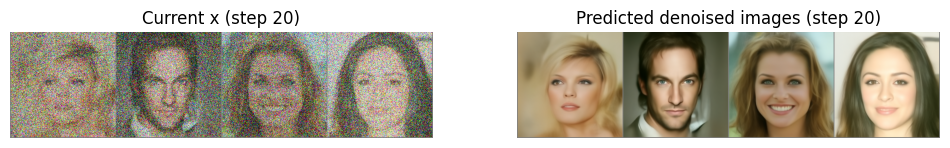

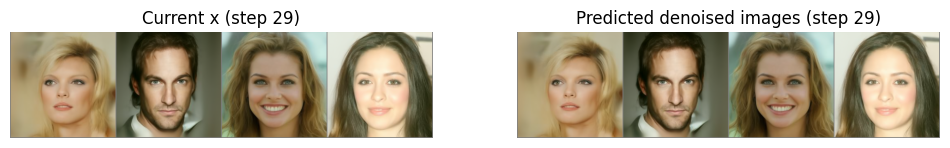

In [15]:
from genaibook.core import plot_noise_and_denoise
image=torch.randn(4,3,256,256).to(de)
image_pipe.scheduler.set_timesteps(num_inference_steps=30)
for i ,t in enumerate(image_pipe.scheduler.timesteps):

    with torch.inference_mode():
        noise_pred=image_pipe.unet(image,t)['sample']
    scheduler_output=image_pipe.scheduler.step(noise_pred,t,image)
    image=scheduler_output.prev_sample

    if i%10==0 or i==len(image_pipe.scheduler.timesteps)-1:
        plot_noise_and_denoise(scheduler_output,i)
    

In [16]:
from datasets import load_dataset
dataset=load_dataset("huggan/smithsonian_butterflies_subset", split="train")

README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

C:\Users\91830\anaconda3\envs\genai_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\91830\.cache\huggingface\hub\datasets--huggan--smithsonian_butterflies_subset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

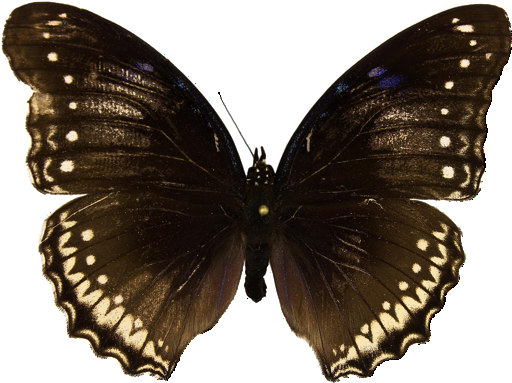

In [23]:
dataset["image"][5]

In [48]:
from torchvision import transforms

image_size=64

preprocess = transforms.Compose(
[
transforms.Resize((image_size, image_size)),  # Resize
transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
transforms.ToTensor(),  # Convert to tensor (0, 1)
transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
]
)

In [49]:
def transform(examples):
    examples=[preprocess(image) for image in examples["image"]]
    return {"images":examples}
dataset.set_transform(transform)
batch_size=16
train_dataloader=torch.utils.data.DataLoader(dataset,batch_size=batch_size,shuffle=True)

In [50]:
from genaibook.core import show_images
batch=next(iter(train_dataloader))


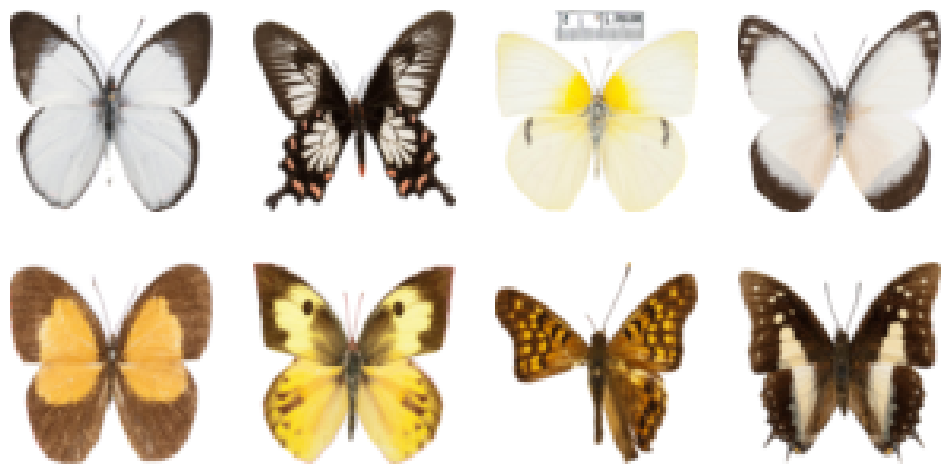

In [52]:
show_images(batch["images"][:8] * 0.5 + 0.5)

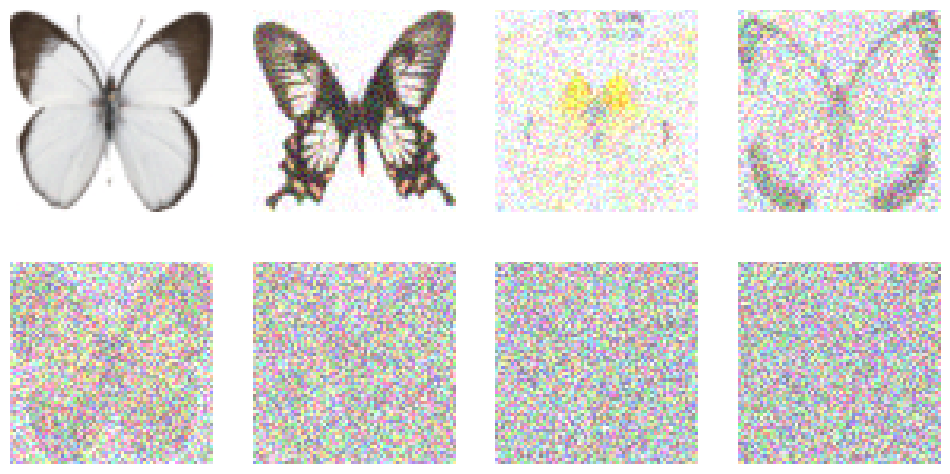

In [54]:
from diffusers import DDPMScheduler
scheduler=DDPMScheduler(num_train_timesteps=1000,beta_start=0.001,beta_end=0.02)
timesteps=torch.linspace(0,999,8).long()
x=batch["images"][:8]
noise=torch.rand_like(x)
noised_x=scheduler.add_noise(x,noise,timesteps)
show_images((noised_x*0.5+0.5).clip(0,1))